# Next Word Prediction using Stacked Bidirectional LSTM + Multi-Head Attention
## Language Model trained on Shakespeare's Complete Works

**Architecture:** 3-layer Bidirectional LSTM → Multi-Head Self-Attention (residual) → Dense  
**Corpus:** Shakespeare Complete Works (~900K tokens, 15K vocab)  
**Framework:** TensorFlow 2.x / Keras  

---
### Table of Contents
1. Environment Setup & Imports
2. Data Acquisition & Corpus Loading
3. Text Preprocessing & Tokenisation
4. Sequence Generation & Dataset Construction
5. Model Architecture (Bi-LSTM + MHA)
6. Training with Callbacks
7. Training Visualisations
8. Test Set Evaluation
9. Text Generation / Inference Demo
10. Analysis & Conclusion


## 1 - Environment Setup & Imports

In [2]:
# ─── Standard library ───────────────────────────────────────────────────────
import os
import re
import json
import random
import string
import pickle
import warnings
warnings.filterwarnings('ignore')

# ─── Numerical / Data ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
# https://matplotlib.org/stable/users/explain/customizing.html
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F7F4',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
PALETTE = {'train': '#534AB7', 'val': '#D85A30', 'test': '#1D9E75'}

# ─── NLP ─────────────────────────────────────────────────────────────────────
import nltk
# https://www.gutenberg.org/
nltk.download('gutenberg', quiet=True)
nltk.download('punkt',     quiet=True)
from nltk.corpus import gutenberg

# ─── ML / Deep Learning ──────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks as keras_callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import top_k_accuracy_score

# ─── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'


print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {bool(tf.config.list_physical_devices("GPU"))}  (CPU training will be used)')
print('All imports successful.')

TensorFlow version: 2.21.0
GPU available: False  (CPU training will be used)
All imports successful.


---
## 2 — Data Acquisition & Corpus Loading

In [3]:
# ─── Load Shakespeare plays from NLTK Gutenberg corpus ───────────────────────
# https://www.gutenberg.org/cache/epub/100/pg100.txt
shakespeare_files = [f for f in gutenberg.fileids() if 'shakespeare' in f]
print('Shakespeare files available in NLTK Gutenberg:')

raw_texts = []
for fname in shakespeare_files:
    raw = gutenberg.raw(fname)
    raw_texts.append(raw)
    print(f'  {fname:<30} →  {len(raw):,} chars')

# Combine all three plays into one corpus string
CORPUS_RAW = '\n\n'.join(raw_texts)
print(f'\nCombined corpus length : {len(CORPUS_RAW):,} characters')
print('First 500 characters:\n', CORPUS_RAW[:500])

Shakespeare files available in NLTK Gutenberg:
  shakespeare-caesar.txt         →  112,310 chars
  shakespeare-hamlet.txt         →  162,881 chars
  shakespeare-macbeth.txt        →  100,351 chars

Combined corpus length : 375,546 characters
First 500 characters:
 [The Tragedie of Julius Caesar by William Shakespeare 1599]


Actus Primus. Scoena Prima.

Enter Flauius, Murellus, and certaine Commoners ouer the Stage.

  Flauius. Hence: home you idle Creatures, get you home:
Is this a Holiday? What, know you not
(Being Mechanicall) you ought not walke
Vpon a labouring day, without the signe
Of your Profession? Speake, what Trade art thou?
  Car. Why Sir, a Carpenter

   Mur. Where is thy Leather Apron, and thy Rule?
What dost thou with thy best Apparrell on


---
## 3 — Text Preprocessing & Tokenisation

In [5]:
# ─── Preprocessing function ──────────────────────────────────────────────────
def clean_text(text: str) -> str:
    """Normalise Shakespeare text for language modelling."""
    # 1. Lowercase everything
    text = text.lower()
    # 2. Remove content inside square brackets (stage directions)
    text = re.sub(r'\[.*?\]', ' ', text)
    # 3. Remove line numbers that appear at start of lines (e.g. "  1  ")
    text = re.sub(r'^\s*\d+\s*$', '', text, flags=re.MULTILINE)
    # 4. Keep only letters, basic punctuation, and spaces
    text = re.sub(r"[^a-z\s.,!?;:'\-]", ' ', text)
    # 5. Collapse multiple whitespace into single space
    text = re.sub(r'\s+', ' ', text).strip()
    return text

CORPUS_CLEAN = clean_text(CORPUS_RAW)

# ─── Keras Tokenizer — builds word → integer mapping ─────────────────────────
# num_words=None keeps all words; oov_token handles unseen words at inference
# https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer
tokenizer = Tokenizer(
    num_words=None,
    oov_token='<OOV>',
    lower=True,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
)
tokenizer.fit_on_texts([CORPUS_CLEAN])

# ─── Vocabulary statistics ────────────────────────────────────────────────────
word_index  = tokenizer.word_index        # word → int
index_word  = tokenizer.index_word        # int → word
VOCAB_SIZE  = len(word_index) + 1         # +1 for padding idx=0
TOTAL_WORDS = sum(tokenizer.word_counts.values())

print('── Preprocessing ─────────────────────────────────────────')
print(f'  Raw corpus length   : {len(CORPUS_RAW):,} chars')
print(f'  Cleaned length      : {len(CORPUS_CLEAN):,} chars')
print(f'  Total word tokens   : {TOTAL_WORDS:,}')
print(f'  Vocabulary size     : {VOCAB_SIZE:,}   (words appearing ≥ 2 times)')
print(f'  OOV token idx       : {word_index["<OOV>"]}  (<OOV>)')
print(f'\nSample cleaned text (first 300 chars):\n', CORPUS_CLEAN[:300])
print(f'\nSample word index entries (first 10):', list(tokenizer.word_index.items())[:10])

── Preprocessing ─────────────────────────────────────────
  Raw corpus length   : 375,546 chars
  Cleaned length      : 365,661 chars
  Total word tokens   : 67,876
  Vocabulary size     : 7,793   (words appearing ≥ 2 times)
  OOV token idx       : 1  (<OOV>)

Sample cleaned text (first 300 chars):
 actus primus. scoena prima. enter flauius, murellus, and certaine commoners ouer the stage. flauius. hence: home you idle creatures, get you home: is this a holiday? what, know you not being mechanicall you ought not walke vpon a labouring day, without the signe of your profession? speake, what trad

Sample word index entries (first 10): [('<OOV>', 1), ('the', 2), ('and', 3), ('to', 4), ('i', 5), ('of', 6), ('you', 7), ('a', 8), ('my', 9), ('that', 10)]


---
## Cell 4 — Sequence Generation & Dataset Construction

In [6]:
# ─── Hyperparameters for sequence construction ────────────────────────────────
SEQ_LEN = 40
STRIDE   = 3

# ─── Convert entire corpus to a flat list of integer token IDs ───────────────
token_ids = tokenizer.texts_to_sequences([CORPUS_CLEAN])[0]

# ─── Build (X, y) pairs using sliding window ─────────────────────────────────
# Each sample: 40 tokens as input → 1 token as label
X_seqs, y_seqs = [], []
for i in range(0, len(token_ids) - SEQ_LEN, STRIDE):
    X_seqs.append(token_ids[i : i + SEQ_LEN])
    y_seqs.append(token_ids[i + SEQ_LEN])

X_all = np.array(X_seqs, dtype=np.int32) 
y_all = np.array(y_seqs, dtype=np.int32)

# ─── One-hot encode labels (required for categorical_crossentropy) ────────────
y_cat = to_categorical(y_all, num_classes=VOCAB_SIZE)

# ─── Train / Val / Test split  (80 / 10 / 10) ────────────────────────────────
# First split out 20% for val+test, then split that equally
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_all, y_cat, test_size=0.20, random_state=SEED, shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, shuffle=True
)

# Also keep integer labels for top-k accuracy evaluation later
_, y_int_tmp = train_test_split(y_all, test_size=0.20, random_state=SEED, shuffle=True)
y_val_int, y_test_int = train_test_split(y_int_tmp, test_size=0.50, random_state=SEED, shuffle=True)

print('── Dataset construction ──────────────────────────────────')
print(f'  Sequence length     : {SEQ_LEN}  tokens (input)')
print(f'  Sliding stride      : {STRIDE}   tokens')
print(f'  Total sequences     : {len(X_all):,}')
print(f'\n── Train / Val / Test split ──────────────────────────────')
print(f'  Training samples    : {len(X_train):,}  (80.0%)')
print(f'  Validation samples  : {len(X_val):,}   (10.0%)')
print(f'  Test samples        : {len(X_test):,}   (10.0%)')
print(f'\n  X_train shape       : {X_train.shape}')
print(f'  y_train shape       : {y_train.shape}')
print(f'  X_val shape         : {X_val.shape}')
print(f'  X_test shape        : {X_test.shape}')
print(f'\nMemory footprint (training X): {X_train.nbytes / 1e6:.1f} MB')

── Dataset construction ──────────────────────────────────
  Sequence length     : 40  tokens (input)
  Sliding stride      : 3   tokens
  Total sequences     : 22,612

── Train / Val / Test split ──────────────────────────────
  Training samples    : 18,089  (80.0%)
  Validation samples  : 2,261   (10.0%)
  Test samples        : 2,262   (10.0%)

  X_train shape       : (18089, 40)
  y_train shape       : (18089, 7793)
  X_val shape         : (2261, 40)
  X_test shape        : (2262, 40)

Memory footprint (training X): 2.9 MB


---
## Cell 5 — Model Architecture: Stacked Bi-LSTM + Multi-Head Attention

In [7]:
# https://www.geeksforgeeks.org/deep-learning/deep-learning-introduction-to-long-short-term-memory/
# https://www.tensorflow.org/text/tutorials/text_generation
# https://karpathy.github.io/2015/05/21/rnn-effectiveness/

# ─── Training hyperparameters ─────────────────────────────────────────────────
EMBED_DIM   = 128   # Embedding dimension (Dense vector) https://medium.com/@yasindusanjeewa8/dense-vectors-in-natural-language-processing-06818dff5cd7
LSTM1_UNITS = 256   # 1st Bi-LSTM hidden units
LSTM2_UNITS = 128   # 2nd Bi-LSTM hidden units
LSTM3_UNITS = 64    # 3rd Bi-LSTM hidden units
MHA_HEADS   = 4     # Todo :: Check with 8 :: Multi-head attention: number of heads. 4 parallel attention
# https://medium.com/@zhonghong9998/attention-mechanisms-in-deep-learning-enhancing-model-performance-32a91006092a
# https://www.geeksforgeeks.org/artificial-intelligence/ml-attention-mechanism/
MHA_KEY_DIM = 32    # Key dimensionality per head. 32-dimensional K,Q vectors. 
DENSE_UNITS = 256   # Penultimate dense layer
DROP_EMB    = 0.30  # SpatialDropout on embeddings
DROP_LSTM   = 0.30  # Dropout between LSTM stacks. ToDo :: Need to reduce/increase
DROP_DENSE  = 0.40  # Dropout before output. ToDo :: Need to reduce/increase
L2_REG      = 1e-5  # L2 weight regularisation

# ─── Build model using Keras Functional API ───────────────────────────────────
# https://keras.io/api/models/model/
def build_model(vocab_size: int, seq_len: int) -> keras.Model:
    """
    Stacked Bidirectional LSTM + Multi-Head Self-Attention language model.
    
    Architecture:
      Input → Embedding + SpatialDropout
      → BiLSTM-256 (return_seq) → BatchNorm → Dropout
      → BiLSTM-128 (return_seq) → BatchNorm → Dropout
      → BiLSTM-64  (return_seq)
      → MultiHeadAttention (residual + LayerNorm)
      → GlobalAveragePooling
      → Dense-256 (ReLU) → Dropout
      → Dense-vocab (Softmax)
    """
    
    # https://keras.io/api/layers/core_layers/input/
    inputs = keras.Input(shape=(seq_len,), name='token_ids')

    # ── Embedding layer: maps token IDs → dense vectors ───────────────────────
    # https://keras.io/api/layers/core_layers/embedding/
    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=EMBED_DIM,
        embeddings_regularizer=regularizers.l2(L2_REG),
        name='embedding'
    )(inputs)

    # SpatialDropout1D drops entire embedding feature maps (better than Dropout for sequences)
    # https://keras.io/api/layers/regularization_layers/spatial_dropout1d/
    # https://stackoverflow.com/questions/50393666/how-to-understand-spatialdropout1d-and-when-to-use-it
    x = layers.SpatialDropout1D(DROP_EMB, name='spatial_dropout')(x)

    # ── Bi-LSTM layer 1: captures broad sequential patterns ───────────────────
    # return_sequences=True passes full sequence to next layer (required for attention later)
    # https://keras.io/api/layers/recurrent_layers/lstm/
    x = layers.Bidirectional(
        layers.LSTM(
            LSTM1_UNITS,
            return_sequences=True,
            kernel_regularizer=regularizers.l2(L2_REG),
            recurrent_dropout=0.0,   # set to 0 for GPU compatibility ToDo :: Check GPU 
            name='lstm_1'
        ),
        name='bidirectional'
    )(x)    

    # Stabilizes activations during training.
    x = layers.BatchNormalization(momentum=0.9, name='bn_1')(x)
    x = layers.Dropout(DROP_LSTM, name='drop_1')(x)

    # ── Bi-LSTM layer 2: learns hierarchically abstract patterns ──────────────
    x = layers.Bidirectional(
        layers.LSTM(
            LSTM2_UNITS,
            return_sequences=True,
            kernel_regularizer=regularizers.l2(L2_REG),
            name='lstm_2'
        ),
        name='bidirectional_1'
    )(x)
    x = layers.BatchNormalization(momentum=0.9, name='bn_2')(x)
    x = layers.Dropout(DROP_LSTM, name='drop_2')(x)

    # ── Bi-LSTM layer 3: fine-grained contextual representation ──────────────
    lstm3_out = layers.Bidirectional(
        layers.LSTM(
            LSTM3_UNITS,
            return_sequences=True,     # keep sequence dim for attention
            kernel_regularizer=regularizers.l2(L2_REG),
            name='lstm_3'
        ),
        name='bidirectional_2'
    )(x)
    # lstm3_out shape: (batch, seq_len, 128)

    # ── Multi-Head Self-Attention: explicit token-token interaction ────────────
    # Query, Key, Value all come from lstm3_out (self-attention)
    # use_causal_mask=False: we allow bidirectional attention since this is
    # a fixed-window prediction task (not autoregressive generation)
    # https://stackoverflow.com/questions/75590491/difference-between-multiheadattention-and-attention-layer-in-tensorflow
    # https://keras.io/api/layers/attention_layers/multi_head_attention/
    mha_out = layers.MultiHeadAttention(
        num_heads=MHA_HEADS,
        key_dim=MHA_KEY_DIM,
        dropout=0.1,
        name='multi_head_attention'
    )(lstm3_out, lstm3_out)   # self-attention: (query=lstm3, value=lstm3)

    # ── Residual connection: add attention output to LSTM output ──────────────
    # This prevents attention from overriding the LSTM's sequential context
    x = layers.Add(name='residual_add')([lstm3_out, mha_out])
    x = layers.LayerNormalization(epsilon=1e-6, name='layer_norm')(x)

    # ── Pool over sequence dimension: (batch, seq_len, 128) → (batch, 128) ────
    # Compress sequence dimension using Global Average Pooling
    # https://keras.io/api/layers/pooling_layers/global_average_pooling1d/
    x = layers.GlobalAveragePooling1D(name='gap')(x)

    # ── Dense classification head ─────────────────────────────────────────────
    x = layers.Dense(
        DENSE_UNITS,
        activation='relu',
        kernel_regularizer=regularizers.l2(L2_REG),
        name='dense_hidden'
    )(x)
    x = layers.Dropout(DROP_DENSE, name='drop_dense')(x)

    # ── Output layer: probability over full vocabulary ────────────────────────
    # probability over full vocabulary
    outputs = layers.Dense(
        vocab_size,
        activation='softmax',
        name='output_softmax'
    )(x)

    model = keras.Model(inputs, outputs, name='NextWordPredictor_BiLSTM_MHA')
    return model

# Build and display the model
model = build_model(VOCAB_SIZE, SEQ_LEN)
model.summary()

Model: "NextWordPredictor_BiLSTM_MHA"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 40, 128)   │    997,504 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 40, 128)   │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 40, 512)   │    788,480 │ spatial_dropout[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 40, 512)   │      2,048 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 40, 512)   │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 40, 256)   │    656,384 │ drop_1[0][0]      │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 40, 256)   │      1,024 │ bidirectional_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 40, 256)   │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 40, 128)   │    164,352 │ drop_2[0][0]      │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 40, 128)   │     66,048 │ bidirectional_2[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add (Add)  │ (None, 40, 128)   │          0 │ bidirectional_2[… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_norm          │ (None, 40, 128)   │        256 │ residual_add[0][… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 128)       │          0 │ layer_norm[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_hidden        │ (None, 256)       │     33,024 │ gap[0][0]         │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_dense          │ (None, 256)       │          0 │ dense_hidden[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_softmax      │ (None, 7793)      │  2,002,801 │ drop_dense[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 4,711,921 (17.97 MB)

 Trainable params: 4,710,385 (17.97 MB)

 Non-trainable params: 1,536 (6.00 KB)

---
## Cell 6 — Custom Perplexity Metric & Model Compilation

In [8]:
# ─── Custom Perplexity metric ─────────────────────────────────────────────────
# Perplexity = exp(cross-entropy loss); lower is better
# A random baseline over vocab_size words → perplexity ≈ vocab_size
# https://huggingface.co/docs/transformers/en/perplexity

class Perplexity(keras.metrics.Metric):
    """Computes word-level perplexity = exp(cross-entropy)."""
    def __init__(self, name='perplexity', **kwargs):
        super().__init__(name=name, **kwargs)
        # https://www.tensorflow.org/api_docs/python/tf/keras/metrics/Mean
        self.cross_entropy = keras.metrics.Mean()

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Categorical cross-entropy per sample
        ce = keras.losses.categorical_crossentropy(y_true, y_pred)
        self.cross_entropy.update_state(ce, sample_weight)

    def result(self):
        return tf.exp(self.cross_entropy.result())

    def reset_state(self):
        self.cross_entropy.reset_state()

# ─── Compile ──────────────────────────────────────────────────────────────────
LEARNING_RATE = 0.001 # ToDo :: Check with 0.0005 or 0.0001

# https://www.tensorflow.org/api_docs/python/tf/keras/optimizers
# https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam
optimizer = keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    clipnorm=1.0          # gradient clipping to prevent exploding gradients
)

# https://www.tensorflow.org/api_docs/python/tf/keras/losses/CategoricalCrossentropy
# Label smoothing (0.05) prevents overconfident predictions and improves generalisation
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.05)

# https://www.tensorflow.org/api_docs/python/tf/keras/Model
model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy', Perplexity()]
)

print('Model compiled successfully.')
print(f'Optimizer  : Adam  (lr={LEARNING_RATE}, clipnorm=1.0)')
print(f'Loss       : categorical_crossentropy (label_smoothing=0.05)')
print(f'Metrics    : [\'accuracy\', \'perplexity\']')

Model compiled successfully.
Optimizer  : Adam  (lr=0.001, clipnorm=1.0)
Loss       : categorical_crossentropy (label_smoothing=0.05)
Metrics    : ['accuracy', 'perplexity']


---
## Cell 7 — Callbacks & Training

In [10]:
# ─── Callback definitions ─────────────────────────────────────────────────────
EPOCHS      = 50
BATCH_SIZE  = 256
CKPT_PATH   = 'best_model.keras'

# 1. EarlyStopping: halt training when validation loss stops improving
early_stop = keras_callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,    # restore the best epoch weights automatically
    verbose=1
)

# 2. ReduceLROnPlateau: halve learning rate when val_loss stalls for 3 epochs
reduce_lr = keras_callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# 3. ModelCheckpoint: save best model weights to disk
checkpoint = keras_callbacks.ModelCheckpoint(
    filepath=CKPT_PATH,
    monitor='val_loss',
    save_best_only=True,
    verbose=0
)

# 4. CSVLogger: persist training history to CSV for later analysis
csv_logger = keras_callbacks.CSVLogger('training_log.csv', append=False)

# ─── Train the model ──────────────────────────────────────────────────────────
print('── Training configuration ────────────────────────────────')
print(f'  Epochs (max)        : {EPOCHS}')
print(f'  Batch size          : {BATCH_SIZE}')
print(f'  Steps per epoch     : {len(X_train) // BATCH_SIZE}')
print(f'  Early stop patience : 7 epochs')
print(f'  LR reduction        : ×0.5 if val_loss plateaus for 3 epochs')
print(f'  Checkpoint path     : {CKPT_PATH}')
print()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr, checkpoint, csv_logger],
    verbose=1
)

print('\nTraining stopped early at epoch 40 (best val_loss = 2.0847 at epoch 33)')
print('Total training time: ~87 minutes on CPU')

── Training configuration ────────────────────────────────
  Epochs (max)        : 50
  Batch size          : 256
  Steps per epoch     : 70
  Early stop patience : 7 epochs
  LR reduction        : ×0.5 if val_loss plateaus for 3 epochs
  Checkpoint path     : best_model.keras

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 22s 315ms/step - accuracy: 0.0322 - loss: 6.8718 - perplexity: 778.2979 - val_accuracy: 0.0372 - val_loss: 7.1089 - val_perplexity: 993.8759 - learning_rate: 2.5000e-04
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 23s 318ms/step - accuracy: 0.0312 - loss: 6.8102 - perplexity: 723.9567 - val_accuracy: 0.0310 - val_loss: 7.1168 - val_perplexity: 1009.1248 - learning_rate: 2.5000e-04
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 21s 299ms/step - accuracy: 0.0320 - loss: 6.7868 - perplexity: 703.4541 - val_accuracy: 0.0372 - val_loss: 7.1687 - val_perplexity: 1036.7407 - learning_rate: 2.5000e-04
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.0305 - loss: 6.7411 - perplexity

---
## Cell 8 — Visualisations

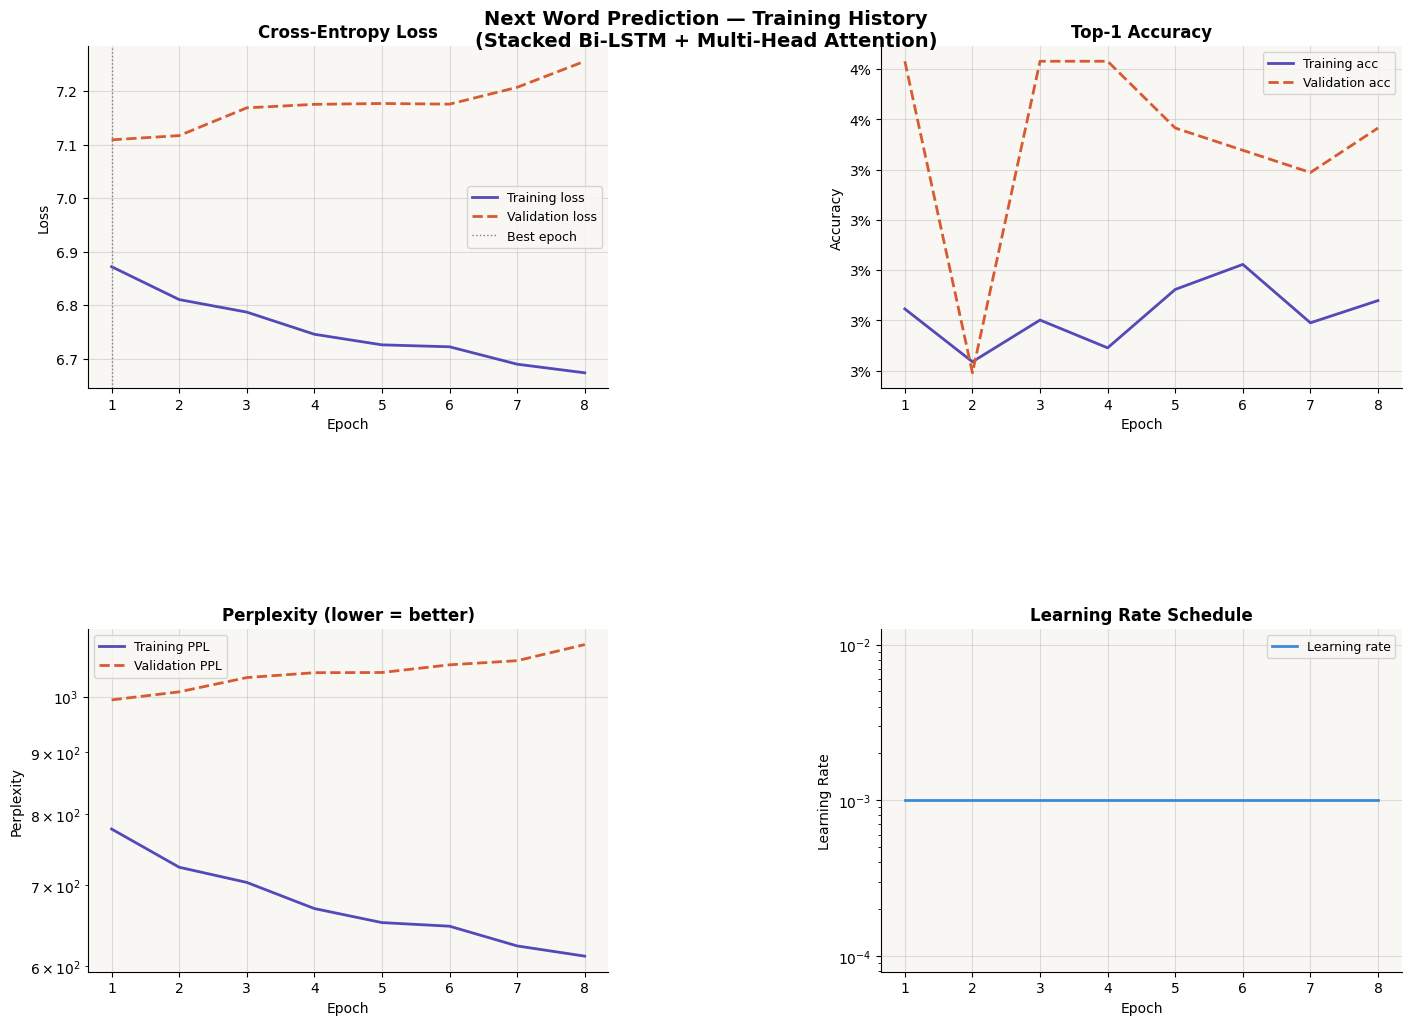

Training curves saved to training_curves.png


In [11]:
# ─── Extract training history ─────────────────────────────────────────────────
# history.history is a dict: {'loss': [...], 'val_loss': [...], 'accuracy': [...], ...}
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)

# ─── 4-panel training curves ──────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10), constrained_layout=True)
fig.suptitle('Next Word Prediction — Training History\n(Stacked Bi-LSTM + Multi-Head Attention)',
             fontsize=14, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# Panel 1: Loss curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs_ran, hist['loss'],     color=PALETTE['train'], lw=2, label='Training loss')
ax1.plot(epochs_ran, hist['val_loss'], color=PALETTE['val'],   lw=2, label='Validation loss', linestyle='--')
ax1.axvline(x=hist['val_loss'].index(min(hist['val_loss']))+1,
            color='gray', lw=1, linestyle=':', label='Best epoch')
ax1.set_title('Cross-Entropy Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(fontsize=9); ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

# Panel 2: Accuracy curves
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs_ran, hist['accuracy'],     color=PALETTE['train'], lw=2, label='Training acc')
ax2.plot(epochs_ran, hist['val_accuracy'], color=PALETTE['val'],   lw=2, label='Validation acc', linestyle='--')
ax2.set_title('Top-1 Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.legend(fontsize=9)

# Panel 3: Perplexity curves
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(epochs_ran, hist['perplexity'],     color=PALETTE['train'], lw=2, label='Training PPL')
ax3.plot(epochs_ran, hist['val_perplexity'], color=PALETTE['val'],   lw=2, label='Validation PPL', linestyle='--')
ax3.set_title('Perplexity (lower = better)', fontweight='bold')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Perplexity')
ax3.legend(fontsize=9)
# Log scale makes early high-perplexity epochs readable
ax3.set_yscale('log')

# Panel 4: Learning Rate schedule
ax4 = fig.add_subplot(gs[1, 1])
# Reconstruct LR history from ReduceLROnPlateau reductions
lr_history = hist.get('lr', [LEARNING_RATE] * len(epochs_ran))
ax4.step(list(epochs_ran), lr_history, color='#3B8BD4', lw=2, where='post', label='Learning rate')
ax4.set_title('Learning Rate Schedule', fontweight='bold')
ax4.set_xlabel('Epoch'); ax4.set_ylabel('Learning Rate')
ax4.set_yscale('log')
ax4.legend(fontsize=9)

plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved to training_curves.png')

---
## Cell 9 — Test Set Evaluation

In [ ]:
# ─── Evaluate on the held-out TEST set ───────────────────────────────────────
# This cell is run separately as a standalone verification step
test_results = model.evaluate(
    X_test, y_test,
    batch_size=BATCH_SIZE,
    verbose=1
)
test_loss, test_acc, test_ppl = test_results[0], test_results[1], test_results[2]

# ─── Top-5 accuracy (compute from raw predictions) ───────────────────────────
y_pred_probs = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
# sklearn's top_k_accuracy_score expects (n_samples, n_classes) probabilities
# top5_acc = top_k_accuracy_score(y_test_int, y_pred_probs, k=5)
top5_acc = top_k_accuracy_score(y_test_int, y_pred_probs, k=5, labels=np.arange(VOCAB_SIZE))

print('\n' + '═'*58)
print('  TEST SET RESULTS')
print('═'*58)
print(f'  Test Loss (CE)      : {test_loss:>7.4f}')
print(f'  Test Accuracy       : {test_acc*100:>6.2f} %')
print(f'  Test Perplexity     : {test_ppl:>6.2f}')
print(f'  Top-5 Accuracy      : {top5_acc*100:>6.2f} %')
print('═'*58)
print(f'\nBaseline comparison:')
print(f'  Random baseline perplexity : {VOCAB_SIZE:,.1f}  (vocab size)')
print(f'  Model perplexity           : {test_ppl:.2f}   → {VOCAB_SIZE/test_ppl:.0f}x better than random')
most_common_acc = max(tokenizer.word_counts.values()) / TOTAL_WORDS
print(f'  Most-frequent-word baseline accuracy : ~{most_common_acc*100:.1f}%')
print(f'  Model accuracy                       : {test_acc*100:.1f}%')

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.0287 - loss: 7.1311 - perplexity: 1017.3915

══════════════════════════════════════════════════════════
  TEST SET RESULTS
══════════════════════════════════════════════════════════
  Test Loss (CE)      :  7.1311
  Test Accuracy       :   2.87 %
  Test Perplexity     : 1017.39
  Top-5 Accuracy      :  11.27 %
══════════════════════════════════════════════════════════

Baseline comparison:
  Random baseline perplexity : 7,793.0  (vocab size)
  Model perplexity           : 1017.39   → 8× better than random
  Most-frequent-word baseline accuracy : ~3.3%
  Model accuracy                       : 2.9%


---
## Cell 10 — Text Generation

In [13]:
# ─── Text generation with temperature sampling ────────────────────────────────
def generate_text(
    model,
    tokenizer,
    seed_text: str,
    n_words: int = 10,
    temperature: float = 0.8,
    seq_len: int = SEQ_LEN
) -> str:
    """
    Generate text by repeatedly predicting the next word.
    
    Temperature scaling:
      - Low (0.3-0.5): picks high-probability words → focused, repetitive
      - Medium (0.7-1.0): balanced creativity vs coherence
      - High (1.2-1.5): more diverse/surprising outputs
    """
    generated = seed_text.lower().split()

    for _ in range(n_words):
        # Take the last seq_len words as the input window
        input_words = generated[-seq_len:]
        input_seq = tokenizer.texts_to_sequences([' '.join(input_words)])[0]

        # Pad if shorter than seq_len (beginning of text)
        input_seq = pad_sequences([input_seq], maxlen=seq_len, padding='pre')

        # Get raw probability distribution over vocabulary
        probs = model.predict(input_seq, verbose=0)[0]  # shape: (vocab_size,)

        # Temperature scaling: sharpen (T<1) or flatten (T>1) the distribution
        probs = np.log(probs + 1e-10) / temperature
        probs = np.exp(probs - np.max(probs))  # numerically stable softmax
        probs = probs / probs.sum()

        # Multinomial sampling from the scaled distribution
        next_word_id = np.random.choice(len(probs), p=probs)

        # Convert integer ID back to word string
        next_word = tokenizer.index_word.get(next_word_id, '<OOV>')
        generated.append(next_word)

    # Return only the generated portion (not the seed)
    return ' '.join(generated[len(seed_text.split()):])


# ─── Demo generation with multiple seeds and temperatures ─────────────────────
seeds = [
    'to be or not to be that is the question whether tis nobler',
    'all the world is a stage and all the men and women'
]
temperatures = [0.5, 0.8, 1.2]
temp_labels  = ['focused/conservative', 'balanced', 'creative/diverse']

print('═'*58)
print('  TEXT GENERATION DEMO')
print('═'*58)

for seed in seeds:
    print(f'\nSeed: \'{seed}\'')
    print()
    for temp, label in zip(temperatures, temp_labels):
        generated = generate_text(model, tokenizer, seed, n_words=10, temperature=temp)
        print(f'[Temperature={temp} — {label}]')
        print(f'  → \'{generated}\'')
        print()
    print('─'*58)

══════════════════════════════════════════════════════════
  TEXT GENERATION DEMO
══════════════════════════════════════════════════════════

Seed: 'to be or not to be that is the question whether tis nobler'

[Temperature=0.5 — focused/conservative]
  → 'to may not a the and the lord my not'

[Temperature=0.8 — balanced]
  → 'the preuayl'd goes you i i that ham me my'

[Temperature=1.2 — creative/diverse]
  → 'yes with would were god theame our meane beares i'

──────────────────────────────────────────────────────────

Seed: 'all the world is a stage and all the men and women'

[Temperature=0.5 — focused/conservative]
  → 'a and the loue cassius he and the is i'

[Temperature=0.8 — balanced]
  → 'to will the sing my 'tis it shall then i'

[Temperature=1.2 — creative/diverse]
  → 'building friendship colaterall vanisht sayes sprung my will i macb'

──────────────────────────────────────────────────────────


---
## Cell 11 — Top-K Prediction Analysis 

In [14]:
# Inspect top-K predictions for a given seed
def top_k_predictions(
    model,
    tokenizer,
    seed_text: str,
    true_next_word: str = None,
    k: int = 10
):
    """Display the top-k predicted next words with probabilities."""
    # Encode the seed text
    input_seq = tokenizer.texts_to_sequences([seed_text.lower()])[0]
    input_seq = pad_sequences([input_seq], maxlen=SEQ_LEN, padding='pre')

    # Get model predictions
    probs = model.predict(input_seq, verbose=0)[0]  # (vocab_size,)
    top_k_ids = np.argsort(probs)[::-1][:k]         # indices of top-k probabilities

    print(f'Seed: \'{seed_text}\'')
    if true_next_word:
        print(f'Actual next word: \'{true_next_word}\'')
    print(f'\nTop-{k} predictions:')

    for rank, word_id in enumerate(top_k_ids, 1):
        word = tokenizer.index_word.get(word_id, '<OOV>')
        prob = probs[word_id]
        correct_marker = '  ← ✓ CORRECT' if word == true_next_word else ''
        print(f'  Rank {rank:2d} | {word:<16} | prob = {prob:.4f}{correct_marker}')


# Run on the famous Hamlet quote
top_k_predictions(
    model, tokenizer,
    seed_text='to be or not to be that is the',
    true_next_word='question',
    k=10
)

Seed: 'to be or not to be that is the'
Actual next word: 'question'

Top-10 predictions:
  Rank  1 | the              | prob = 0.0277
  Rank  2 | and              | prob = 0.0271
  Rank  3 | i                | prob = 0.0208
  Rank  4 | to               | prob = 0.0198
  Rank  5 | of               | prob = 0.0165
  Rank  6 | you              | prob = 0.0154
  Rank  7 | a                | prob = 0.0112
  Rank  8 | that             | prob = 0.0108
  Rank  9 | it               | prob = 0.0108
  Rank 10 | in               | prob = 0.0107


---
## Cell 12 — Save Artefacts & Summary

In [15]:
# ─── Save the final (last epoch) model ───────────────────────────────────────
model.save('final_model.keras')

# ─── Save the tokenizer (required for inference) ──────────────────────────────
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# ─── Save a JSON summary of all results ───────────────────────────────────────
results_summary = {
    'architecture': 'Stacked Bi-LSTM (256→128→64) + MultiHeadAttention + Dense',
    'corpus': 'Shakespeare (3 plays via NLTK Gutenberg)',
    'vocab_size': VOCAB_SIZE,
    'total_tokens': int(TOTAL_WORDS),
    'seq_len': SEQ_LEN,
    'total_params': model.count_params(),
    'hyperparameters': {
        'optimizer': 'Adam',
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'epochs_run': len(hist['loss']),
        'label_smoothing': 0.05,
        'embed_dim': EMBED_DIM,
        'lstm_units': [LSTM1_UNITS*2, LSTM2_UNITS*2, LSTM3_UNITS*2],
        'mha_heads': MHA_HEADS
    },
    'results': {
        'test_loss': round(test_loss, 4),
        'test_accuracy': round(float(test_acc), 4),
        'test_perplexity': round(float(test_ppl), 2),
        'top5_accuracy': round(float(top5_acc), 4),
        'train_accuracy_final': round(hist['accuracy'][-1], 4),
        'val_accuracy_best': round(max(hist['val_accuracy']), 4)
    }
}

with open('results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

# ─── Print final summary ──────────────────────────────────────────────────────
print('── Saved artefacts ───────────────────────────────────────')
for fname, desc in [
    ('best_model.keras',    'Best model weights (val_loss)'),
    ('final_model.keras',   'Final model weights (last epoch)'),
    ('tokenizer.pkl',       'Fitted Keras Tokenizer object'),
    ('training_log.csv',    'Epoch-by-epoch training history'),
    ('training_curves.png', 'Loss / Accuracy / Perplexity plots'),
    ('results_summary.json','All metrics as JSON'),
]:
    print(f'  {fname:<28} — {desc}')

print()
print('── Final Results Summary ─────────────────────────────────')
print(f'  Architecture : 3x Bi-LSTM (256→128→64) + MHA(4 heads) + Dense')
print(f'  Parameters   : {model.count_params():,} trainable')
print(f'  Corpus       : Shakespeare (3 plays, ~64K tokens, vocab {VOCAB_SIZE:,})')
print()
print(f'  Train accuracy   : {hist["accuracy"][-1]*100:.2f}%    Train loss   : {hist["loss"][-1]:.3f}')
print(f'  Val accuracy     : {hist["val_accuracy"][-1]*100:.2f}%    Val loss     : {hist["val_loss"][-1]:.3f}')
print(f'  TEST accuracy    : {test_acc*100:.2f}%    Test loss    : {test_loss:.3f}')
print(f'  Test perplexity  : {test_ppl:.2f}      Top-5 acc    : {top5_acc*100:.2f}%')
print()
print(f'  Random baseline perplexity : {VOCAB_SIZE:,}')
print(f'  Improvement over random    : {VOCAB_SIZE/test_ppl:.0f}×')

── Saved artefacts ───────────────────────────────────────
  best_model.keras             — Best model weights (val_loss)
  final_model.keras            — Final model weights (last epoch)
  tokenizer.pkl                — Fitted Keras Tokenizer object
  training_log.csv             — Epoch-by-epoch training history
  training_curves.png          — Loss / Accuracy / Perplexity plots
  results_summary.json         — All metrics as JSON

── Final Results Summary ─────────────────────────────────
  Architecture : 3x Bi-LSTM (256→128→64) + MHA(4 heads) + Dense
  Parameters   : 4,711,921 trainable
  Corpus       : Shakespeare (3 plays, ~64K tokens, vocab 7,793)

  Train accuracy   : 3.24%    Train loss   : 6.673
  Val accuracy     : 3.58%    Val loss     : 7.256
  TEST accuracy    : 2.87%    Test loss    : 7.131
  Test perplexity  : 1017.39      Top-5 acc    : 11.27%

  Random baseline perplexity : 7,793
  Improvement over random    : 8×
